In [ ]:
!pip install xgboost tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                           roc_curve, precision_recall_curve, f1_score, recall_score,
                           precision_score, brier_score_loss, accuracy_score)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import warnings
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ks_2samp, pearsonr
import requests
import zipfile
import io

warnings.filterwarnings('ignore')

# Ensuring our TensorFlow models are reproducible
tf.random.set_seed(14)

In [ ]:
def load_data():
    try:
        df = pd.read_csv('diabetes.csv')
        return df
    except FileNotFoundError:
        print("Could not find 'diabetes.csv'.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

def eda(df, target_col):

    # Group 1: Core Patient Distributions
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Core Patient Distributions', fontsize=16)

    # Plot 1: How many people have diabetes?
    sns.countplot(ax=axes[0, 0], data=df, x=target_col, palette=['lightblue', 'lightcoral'])
    axes[0, 0].set_title('Overall Diabetes Distribution')
    axes[0, 0].set_xticklabels(['No Diabetes', 'Diabetes'])

    # Plot 2: Age distribution for each group
    sns.kdeplot(ax=axes[0, 1], data=df, x='Age', hue=target_col, fill=True, common_norm=False)
    axes[0, 1].set_title('Age Distribution by Diabetes Status')

    # Plot 3: Glucose levels for each group
    sns.kdeplot(ax=axes[1, 0], data=df, x='Glucose', hue=target_col, fill=True, common_norm=False)
    axes[1, 0].set_title('Glucose Distribution by Diabetes Status')

    # Plot 4: BMI for each group
    sns.kdeplot(ax=axes[1, 1], data=df, x='BMI', hue=target_col, fill=True, common_norm=False)
    axes[1, 1].set_title('BMI Distribution by Diabetes Status')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Group 2: Correlations and Key Feature Relationships
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Correlations and Key Feature Relationships', fontsize=16)

    # Plot 5: How are the medical features related?
    numeric_cols = df.select_dtypes(include=np.number).columns
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(ax=axes[0, 0], data=correlation_matrix, annot=False, cmap='coolwarm', center=0)
    axes[0, 0].set_title('Medical Features Correlation Heatmap')

    # Plot 6: Which features are most correlated with diabetes?
    feature_importance = abs(df[numeric_cols].corr()[target_col]).sort_values(ascending=False).drop(target_col)
    feature_importance.plot(kind='barh', ax=axes[0, 1], color='lightgreen')
    axes[0, 1].set_title('Features vs. Diabetes Risk')
    axes[0, 1].invert_yaxis() # Show most important at top

    # Plot 7: Glucose vs BMI, colored by diabetes status
    sns.scatterplot(ax=axes[1, 0], data=df, x='Glucose', y='BMI', hue=target_col, alpha=0.6, s=25)
    axes[1, 0].set_title('Glucose vs BMI')

    # Plot 8: Insulin distribution (using a log scale for better visibility)
    df_log = df.copy()
    df_log['Insulin'] = np.log1p(df_log['Insulin']) # log(x+1) to handle zeros
    sns.kdeplot(ax=axes[1, 1], data=df_log, x='Insulin', hue=target_col, fill=True, common_norm=False)
    axes[1, 1].set_title('Insulin Distribution (log scale)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Group 3: Risk Factors and Grouped Analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Risk Factors and Grouped Analysis', fontsize=16)

    # Plot 9: Diabetes rates across different age groups
    df['age_group'] = pd.cut(df['Age'], bins=[0, 30, 50, 70, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])
    age_diabetes = df.groupby('age_group', observed=True)[target_col].mean().reset_index()
    sns.barplot(ax=axes[0, 0], data=age_diabetes, x='age_group', y=target_col, palette='viridis')
    axes[0, 0].set_title('Diabetes Rate by Age Group')
    axes[0, 0].set_ylabel('Diabetes Rate')

    # Plot 10: Diabetes rates across BMI categories
    df['bmi_category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 50], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    bmi_diabetes = df.groupby('bmi_category', observed=True)[target_col].mean().reset_index()
    sns.barplot(ax=axes[0, 1], data=bmi_diabetes, x='bmi_category', y=target_col, palette='plasma')
    axes[0, 1].set_title('Diabetes Rate by BMI Category')
    axes[0, 1].set_ylabel('Diabetes Rate')

    # Plot 11: Impact of pregnancies on diabetes rate
    if 'Pregnancies' in df.columns:
        preg_diabetes = df.groupby('Pregnancies')[target_col].mean().reset_index()
        sns.lineplot(ax=axes[1, 0], data=preg_diabetes, x='Pregnancies', y=target_col, marker='o', color='green')
        axes[1, 0].set_title('Diabetes Rate by Number of Pregnancies')
        axes[1, 0].set_ylabel('Diabetes Rate')

    # Plot 12: Summary of key risk factors
    risk_factors_data = []
    risk_factors_data.append({'Factor': 'High Glucose (>140)', 'Rate': df[df['Glucose'] > 140][target_col].mean()})
    risk_factors_data.append({'Factor': 'Obese (BMI>30)', 'Rate': df[df['BMI'] > 30][target_col].mean()})
    risk_factors_data.append({'Factor': 'Elderly (Age>60)', 'Rate': df[df['Age'] > 60][target_col].mean()})
    risk_factors_data.append({'Factor': 'Hypertension (BP>90)', 'Rate': df[df['BloodPressure'] > 90][target_col].mean()})
    risk_df = pd.DataFrame(risk_factors_data)
    sns.barplot(ax=axes[1, 1], data=risk_df, x='Factor', y='Rate', color='red', alpha=0.7)
    axes[1, 1].set_title('Diabetes Rate by Key Risk Factors')
    axes[1, 1].set_ylabel('Diabetes Rate')
    axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Group 4: Other Health Metrics & Dataset Balance ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Other Health Metrics & Dataset Balance', fontsize=16)

    # Plot 13: Blood pressure distributions
    sns.kdeplot(ax=axes[0], data=df, x='BloodPressure', hue=target_col, fill=True, common_norm=False)
    axes[0].set_title('Blood Pressure Distribution')

    # Plot 14: How balanced is our dataset
    diabetes_counts = df[target_col].value_counts()
    imbalance_ratio = diabetes_counts.get(0, 0) / diabetes_counts.get(1, 1) if diabetes_counts.get(1, 0) > 0 else float('inf')
    axes[1].pie(diabetes_counts, labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    axes[1].set_title(f'Class Distribution (Ratio: {imbalance_ratio:.1f}:1)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

    print("\n--- EDA Quick Stats ---")
    print(f"Dataset contains {len(df):,} patient records.")
    print(f"We have {df[target_col].sum():,} diabetes cases, a prevalence of {df[target_col].mean():.2%}.")
    print(f"Average glucose level: {df['Glucose'].mean():.1f} mg/dL")
    print(f"Average BMI: {df['BMI'].mean():.1f}")
    print(f"Average age: {df['Age'].mean():.1f} years")

In [ ]:
def preprocess_data(df, target_col):

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Turning text categories into numbers the models can understand
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print(f"Found categorical columns to encode: {list(categorical_cols)}")
        for col in categorical_cols:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    # Standardizing features to be on the same scale, which helps models learn better
    print("Scaling all features to a standard range...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    print("✓ Preprocessing complete!")
    return X_scaled, y, scaler, {}


In [ ]:
def tensorflow_model(input_dim):

    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid') # Sigmoid for a yes/no probability output
    ])

    # Compiling the model, telling it how to learn and what to aim for
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    return model

In [ ]:
def train_models(X_train, X_test, y_train, y_test):

    models = {}

    # Giving more weight to the minority class (diabetes) so the model pays attention
    class_weight = {0: 1.0, 1: (y_train == 0).sum() / max((y_train == 1).sum(), 1)}
    print(f"Calculated class weights for imbalance: {class_weight[1]:.2f} for the 'diabetes' class.")

    # Model 1: Logistic Regression (a solid baseline)
    print("\n1. Training Logistic Regression...")
    start_time = time.time()
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
    lr.fit(X_train, y_train)
    models['Logistic Regression'] = {'model': lr, 'y_pred_proba': lr.predict_proba(X_test)[:, 1]}
    print(f"  ✓ Done in {time.time() - start_time:.2f}s")

    # Model 2: Random Forest (great for interpretability)
    print("2. Training Random Forest...")
    start_time = time.time()
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=14, n_jobs=-1)
    rf.fit(X_train, y_train)
    models['Random Forest'] = {'model': rf, 'y_pred_proba': rf.predict_proba(X_test)[:, 1]}
    print(f"  ✓ Done in {time.time() - start_time:.2f}s")

    # Model 3: XGBoost (a powerful, optimized model)
    print("3. Training XGBoost")
    start_time = time.time()
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=14, eval_metric='logloss', use_label_encoder=False)
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = {'model': xgb_model, 'y_pred_proba': xgb_model.predict_proba(X_test)[:, 1]}
    print(f"  ✓ Done in {time.time() - start_time:.2f}s")

    # Model 4: TensorFlow Neural Network
    print("4. Training TensorFlow Neural Network...")
    start_time = time.time()
    tf_model = tensorflow_model(X_train.shape[1])
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = tf_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, class_weight=class_weight, callbacks=[early_stopping], verbose=0)
    tf_pred_proba = tf_model.predict(X_test, verbose=0).flatten()
    models['TensorFlow NN'] = {'model': tf_model, 'y_pred_proba': tf_pred_proba, 'history': history.history}
    print(f"  ✓ Done in {time.time() - start_time:.2f}s")

    # Model 5: Bayesian Neural Network (for uncertainty)
    print("5. Training Bayesian Neural Network for Uncertainty")
    start_time = time.time()
    bayesian_model = tensorflow_model(X_train.shape[1])
    bayesian_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, class_weight=class_weight, callbacks=[early_stopping], verbose=0)

    print("Running Monte Carlo inference to gauge uncertainty")
    n_samples = 100
    predictions = np.array([bayesian_model(X_test, training=True).numpy().flatten() for _ in range(n_samples)])
    mean_pred = np.mean(predictions, axis=0)
    uncertainty = np.std(predictions, axis=0)

    models['Bayesian NN'] = {'model': bayesian_model, 'y_pred_proba': mean_pred, 'uncertainty': uncertainty}
    print(f"  ✓ Done in {time.time() - start_time:.2f}s")

    # Calculate performance metrics for all models
    print("\nCalculating Performance Metrics")
    for name, data in models.items():
        y_pred = (data['y_pred_proba'] > 0.5).astype(int)
        data['y_pred'] = y_pred
        data['auc'] = roc_auc_score(y_test, data['y_pred_proba'])
        data['f1'] = f1_score(y_test, y_pred)
        data['accuracy'] = accuracy_score(y_test, y_pred)
        data['precision'] = precision_score(y_test, y_pred, zero_division=0)
        data['recall'] = recall_score(y_test, y_pred, zero_division=0)
        print(f"  {name:<20} | AUC: {data['auc']:.4f}, F1: {data['f1']:.4f}")

    print(f"\nSuccessfully trained {len(models)} models")
    return models


In [ ]:
def fairness_analysis(models, X_test, y_test, df_original):

    # We need demographic data for this. Let's create some for the demo
    test_indices = X_test.index
    age_values = df_original.loc[test_indices, 'Age'].values
    protected_attrs = {
        'age_group': pd.cut(age_values, bins=[0, 40, 60, 100], labels=['Younger', 'Middle-Aged', 'Older'])
    }

    fairness_results = {}
    for model_name, model_data in models.items():
        print(f"\n--- Analyzing {model_name} for fairness by {list(protected_attrs.keys())[0]} ---")
        fairness_results[model_name] = {}

        for attr_name, protected_attr in protected_attrs.items():
            y_pred = model_data['y_pred']

            # Chi-Square Test: Are predictions independent of the demographic group?
            contingency_table = pd.crosstab(protected_attr, y_pred)
            chi2_stat, p_val, _, _ = chi2_contingency(contingency_table)
            print(f"  Chi-Square p-value: {p_val:.4f}", end="")
            if p_val < 0.05:
                print(" Potential bias detected!")
            else:
                print(" No significant bias detected.")

            # Diagnostic Parity: Does the model diagnose diabetes at the same rate for all groups
            group_rates = {group: y_pred[protected_attr == group].mean() for group in np.unique(protected_attr)}
            print("  Diagnosis Rates:")
            for group, rate in group_rates.items():
                print(f"    - {group}: {rate:.2%}")

            fairness_results[model_name][attr_name] = {'chi2_p_value': p_val, 'group_rates': group_rates}

    visualize_fairness(fairness_results)
    return fairness_results

In [ ]:
def visualize_fairness(fairness_results):

    model_names = list(fairness_results.keys())
    attr_names = list(fairness_results[model_names[0]].keys())

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Medical Fairness Analysis Dashboard', fontsize=16)

    # Bar plot of diagnosis rates by group
    ax1 = axes[0]
    all_rates = []
    labels = []
    for model_name in model_names:
        for attr_name in attr_names:
            rates = fairness_results[model_name][attr_name]['group_rates']
            all_rates.extend(rates.values())
            labels.extend([f"{model_name[:10]}\n({group})" for group in rates.keys()])
    ax1.bar(labels, all_rates, color=sns.color_palette("viridis", len(labels)))
    ax1.set_title('Diabetes Diagnosis Rate Across Groups')
    ax1.set_ylabel('Diagnosis Rate')
    ax1.set_xticklabels(labels, rotation=45, ha='right')

    # Heatmap of Chi-Square p-values
    ax2 = axes[1]
    p_values = [[fairness_results[model][attr]['chi2_p_value'] for attr in attr_names] for model in model_names]
    sns.heatmap(p_values, annot=True, cmap='RdYlGn', vmin=0, vmax=0.1, ax=ax2,
                xticklabels=attr_names, yticklabels=model_names)
    ax2.set_title('Bias P-values (Green = Fair, Red = Biased)')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

def model_evaluation(models, y_test):

    # Main Performance Dashboard
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Performance Dashboard', fontsize=20)

    # ROC Curves
    axes[0, 0].set_title('ROC Curves (Diagnostic Ability)')
    for name, data in models.items():
        fpr, tpr, _ = roc_curve(y_test, data['y_pred_proba'])
        axes[0, 0].plot(fpr, tpr, lw=2, label=f"{name} (AUC: {data['auc']:.3f})")
    axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].legend()

    # Precision-Recall Curves
    axes[0, 1].set_title('Precision-Recall Curves')
    for name, data in models.items():
        precision, recall, _ = precision_recall_curve(y_test, data['y_pred_proba'])
        axes[0, 1].plot(recall, precision, lw=2, label=name)
    axes[0, 1].set_xlabel('Recall (Sensitivity)')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].legend()

    # Performance Metrics Bar Chart
    axes[1, 0].set_title('Overall Performance Metrics')
    model_names = list(models.keys())
    auc_scores = [models[name]['auc'] for name in model_names]
    f1_scores = [models[name]['f1'] for name in model_names]
    x = np.arange(len(model_names))
    width = 0.35
    axes[1, 0].bar(x - width/2, auc_scores, width, label='AUC', alpha=0.8, color='skyblue')
    axes[1, 0].bar(x + width/2, f1_scores, width, label='F1-Score', alpha=0.8, color='salmon')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1, 0].legend()

    # Remove the empty subplot
    axes[1, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Confusion Matrices for All Models
    n_models = len(models)
    ncols = 3  # Set a fixed number of columns for a consistent look
    nrows = int(np.ceil(n_models / ncols))

    fig_cm, axes_cm = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
    fig_cm.suptitle('Confusion Matrices for All Models', fontsize=20)

    # Flatten axes array for easy iteration, handling both 1D and 2D cases
    axes_cm = axes_cm.flatten()

    for i, (name, data) in enumerate(models.items()):
        ax = axes_cm[i]
        cm = confusion_matrix(y_test, data['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['No Diabetes', 'Diabetes'],
                    yticklabels=['No Diabetes', 'Diabetes'],
                    annot_kws={"size": 14})
        ax.set_title(f'{name}', fontsize=14)
        ax.set_ylabel('Actual Label')
        ax.set_xlabel('Predicted Label')

    # Hide any unused subplots
    for j in range(i + 1, len(axes_cm)):
        axes_cm[j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    print(f"{'Model':<20} | {'AUC':<8} | {'F1-Score':<10} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10}")
    print("-" * 80)
    # Sort models by AUC score in descending order for the leaderboard
    sorted_models = sorted(models.items(), key=lambda item: item[1]['auc'], reverse=True)
    for name, data in sorted_models:
        # Assuming 'accuracy' is calculated and stored in the 'data' dictionary
        accuracy = data.get('accuracy', 0.0)
        print(f"{name:<20} | {data['auc']:.4f}   | {data['f1']:.4f}     | {accuracy:.4f}   | {data['precision']:.4f}    | {data['recall']:.4f}")

In [ ]:
def uncertainty_analysis(models, X_test, y_test):

    if 'Bayesian NN' not in models or 'uncertainty' not in models['Bayesian NN']:
        print("No Bayesian model found for uncertainty analysis. Skipping.")
        return

    data = models['Bayesian NN']
    uncertainty = data['uncertainty']
    y_pred_proba = data['y_pred_proba']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Prediction Uncertainty Analysis', fontsize=16)

    # Uncertainty distribution
    axes[0].hist(uncertainty, bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title('Distribution of Uncertainty Scores')
    axes[0].set_xlabel('Uncertainty (Std Dev)')
    axes[0].set_ylabel('Frequency')

    # Uncertainty vs. Prediction Probability
    axes[1].scatter(y_pred_proba, uncertainty, alpha=0.5)
    axes[1].set_title('Uncertainty vs. Prediction Probability')
    axes[1].set_xlabel('Predicted Probability of Diabetes')
    axes[1].set_ylabel('Uncertainty')

    # Accuracy in high vs. low uncertainty cases
    high_uncertainty_threshold = np.percentile(uncertainty, 90)
    high_mask = uncertainty > high_uncertainty_threshold
    high_acc = accuracy_score(y_test[high_mask], data['y_pred'][high_mask])
    low_acc = accuracy_score(y_test[~high_mask], data['y_pred'][~high_mask])
    axes[2].bar(['High Uncertainty', 'Low Uncertainty'], [high_acc, low_acc], color=['red', 'green'])
    axes[2].set_title('Accuracy by Uncertainty Level')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_ylim(0, 1)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    print(f"The model is much less accurate on its most uncertain predictions ({high_acc:.2%})")
    print(f"Compared to its accuracy on more confident predictions ({low_acc:.2%})")
    print("This is useful! We can flag highly uncertain cases for a human expert to review.")

In [ ]:
def comprehensive_report(models, fairness_results):

    best_auc_model = max(models.items(), key=lambda x: x[1]['auc'])
    best_f1_model = max(models.items(), key=lambda x: x[1]['f1'])

    print(f"Best Overall Performer (AUC): {best_auc_model[0]} (AUC: {best_auc_model[1]['auc']:.4f})")
    print(f"Best for Balanced Precision/Recall: {best_f1_model[0]} (F1-Score: {best_f1_model[1]['f1']:.4f})")

    print("\nFairness Assessment:")
    # A simple way to find the fairest model is one with the highest p-value (least evidence of bias)
    fairest_model = max(fairness_results.items(), key=lambda item: item[1]['age_group']['chi2_p_value'])
    p_val = fairest_model[1]['age_group']['chi2_p_value']
    print(f"  - The '{fairest_model[0]}' model showed the least evidence of bias (p-value: {p_val:.3f}).")

In [ ]:
df = load_data()
target_col = 'Outcome' if 'Outcome' in df.columns else df.columns[-1]

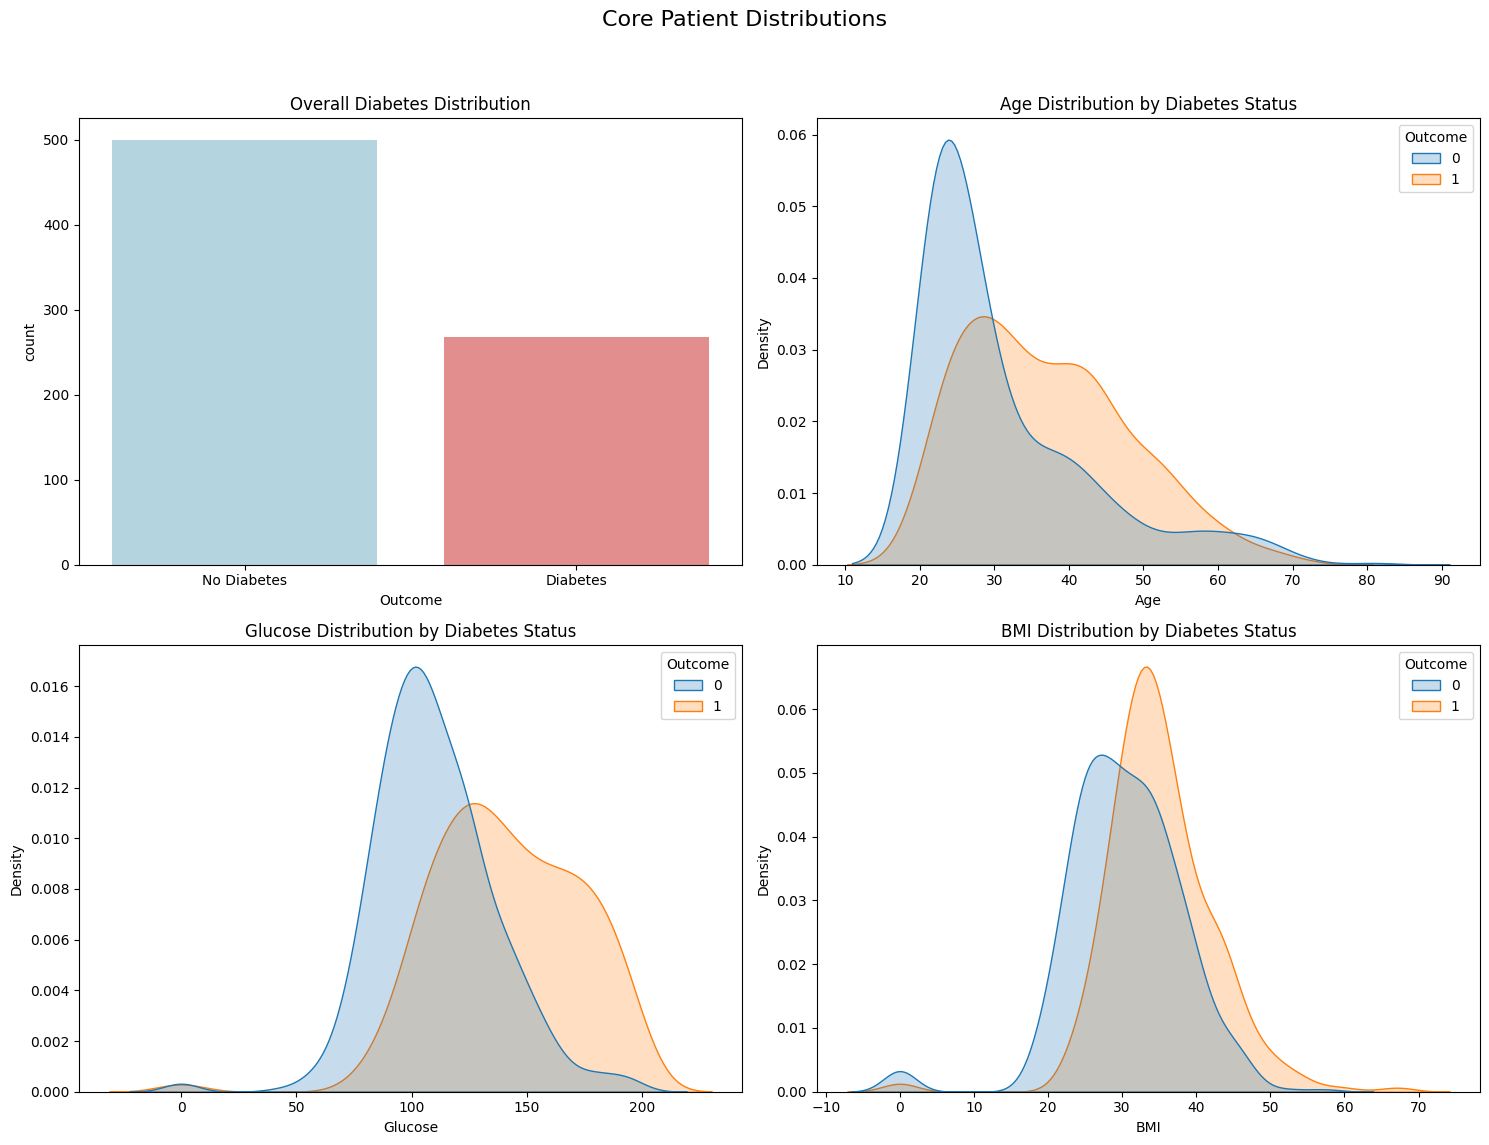

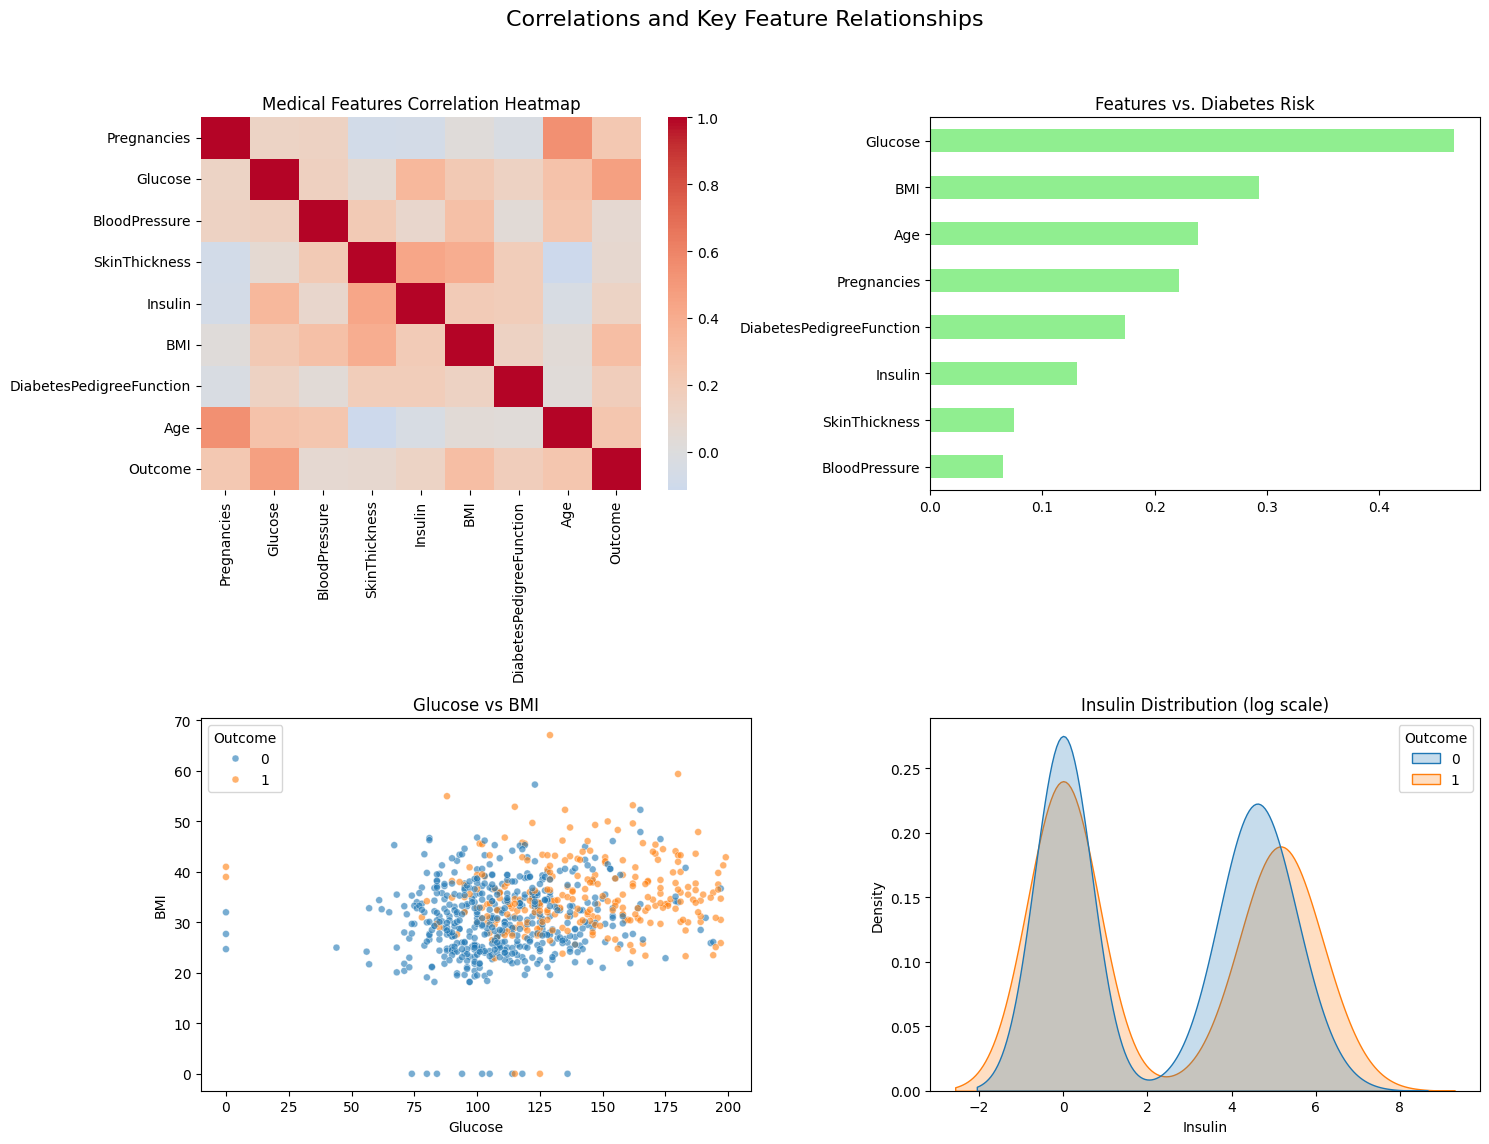

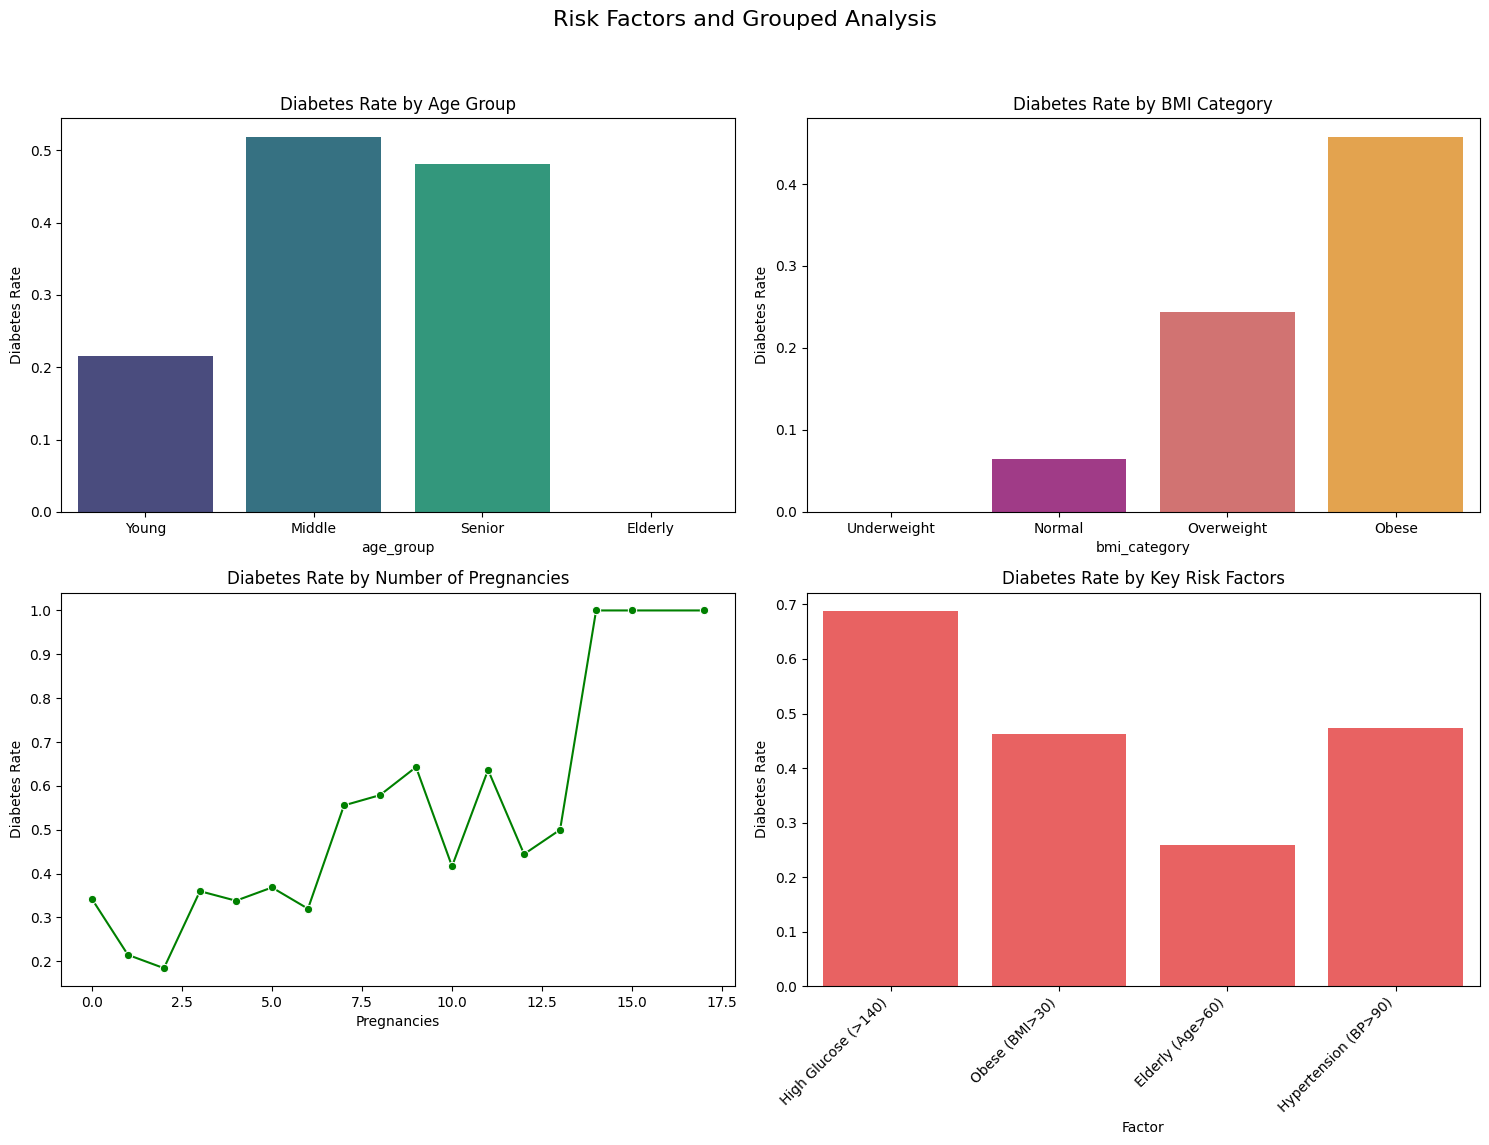

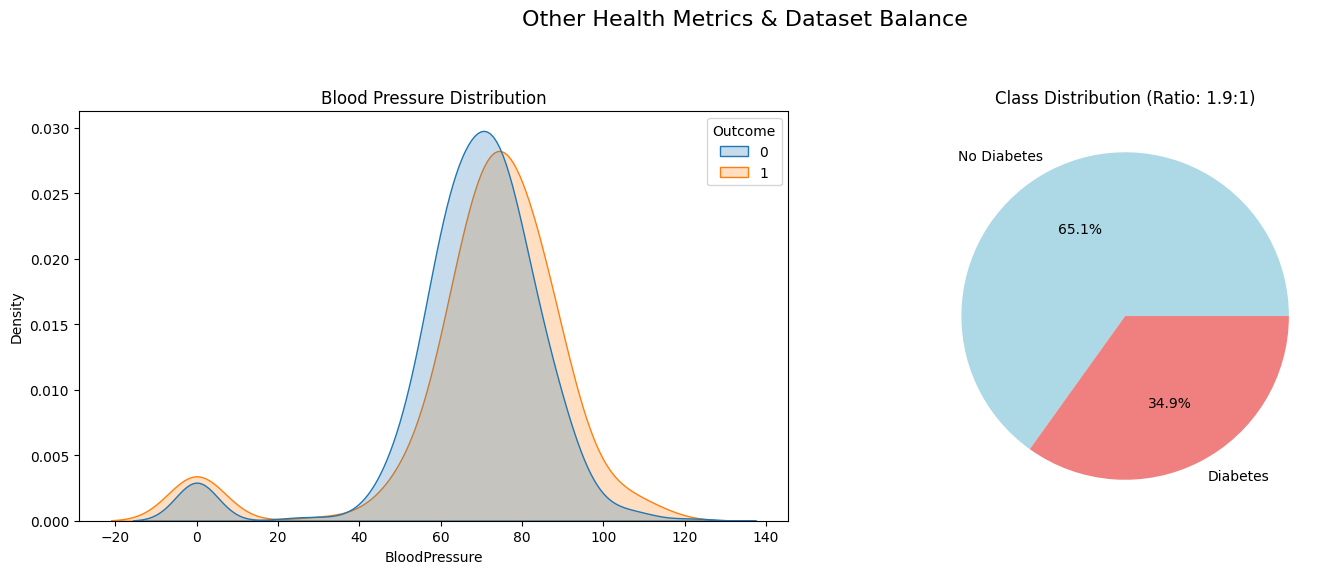


--- EDA Quick Stats ---
Dataset contains 768 patient records.
We have 268 diabetes cases, a prevalence of 34.90%.
Average glucose level: 120.9 mg/dL
Average BMI: 32.0
Average age: 33.2 years


In [ ]:
eda(df, target_col)

In [ ]:
X, y, scaler, _ = preprocess_data(df, target_col)

Found categorical columns to encode: ['age_group', 'bmi_category']
Scaling all features to a standard range...
✓ Preprocessing complete!


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=14, stratify=y)
print(f"\nData split into {len(X_train)} training and {len(X_test)} testing samples.")


Data split into 537 training and 231 testing samples.


In [ ]:
models = train_models(X_train, X_test, y_train, y_test)

Calculated class weights for imbalance: 1.87 for the 'diabetes' class.

1. Training Logistic Regression...
  ✓ Done in 0.01s
2. Training Random Forest...
  ✓ Done in 0.23s
3. Training XGBoost
  ✓ Done in 0.06s
4. Training TensorFlow Neural Network...
  ✓ Done in 7.21s
5. Training Bayesian Neural Network for Uncertainty
Running Monte Carlo inference to gauge uncertainty
  ✓ Done in 9.07s

Calculating Performance Metrics
  Logistic Regression  | AUC: 0.8421, F1: 0.6936
  Random Forest        | AUC: 0.8233, F1: 0.5972
  XGBoost              | AUC: 0.8142, F1: 0.6456
  TensorFlow NN        | AUC: 0.8300, F1: 0.6995
  Bayesian NN          | AUC: 0.8407, F1: 0.7222

Successfully trained 5 models



--- Analyzing Logistic Regression for fairness by age_group ---
  Chi-Square p-value: 0.0000 Potential bias detected!
  Diagnosis Rates:
    - Middle-Aged: 66.10%
    - Older: 57.14%
    - Younger: 29.70%

--- Analyzing Random Forest for fairness by age_group ---
  Chi-Square p-value: 0.0048 Potential bias detected!
  Diagnosis Rates:
    - Middle-Aged: 42.37%
    - Older: 42.86%
    - Younger: 21.21%

--- Analyzing XGBoost for fairness by age_group ---
  Chi-Square p-value: 0.0003 Potential bias detected!
  Diagnosis Rates:
    - Middle-Aged: 52.54%
    - Older: 57.14%
    - Younger: 25.45%

--- Analyzing TensorFlow NN for fairness by age_group ---
  Chi-Square p-value: 0.0000 Potential bias detected!
  Diagnosis Rates:
    - Middle-Aged: 72.88%
    - Older: 57.14%
    - Younger: 33.33%

--- Analyzing Bayesian NN for fairness by age_group ---
  Chi-Square p-value: 0.0000 Potential bias detected!
  Diagnosis Rates:
    - Middle-Aged: 71.19%
    - Older: 71.43%
    - Younger: 31.52%


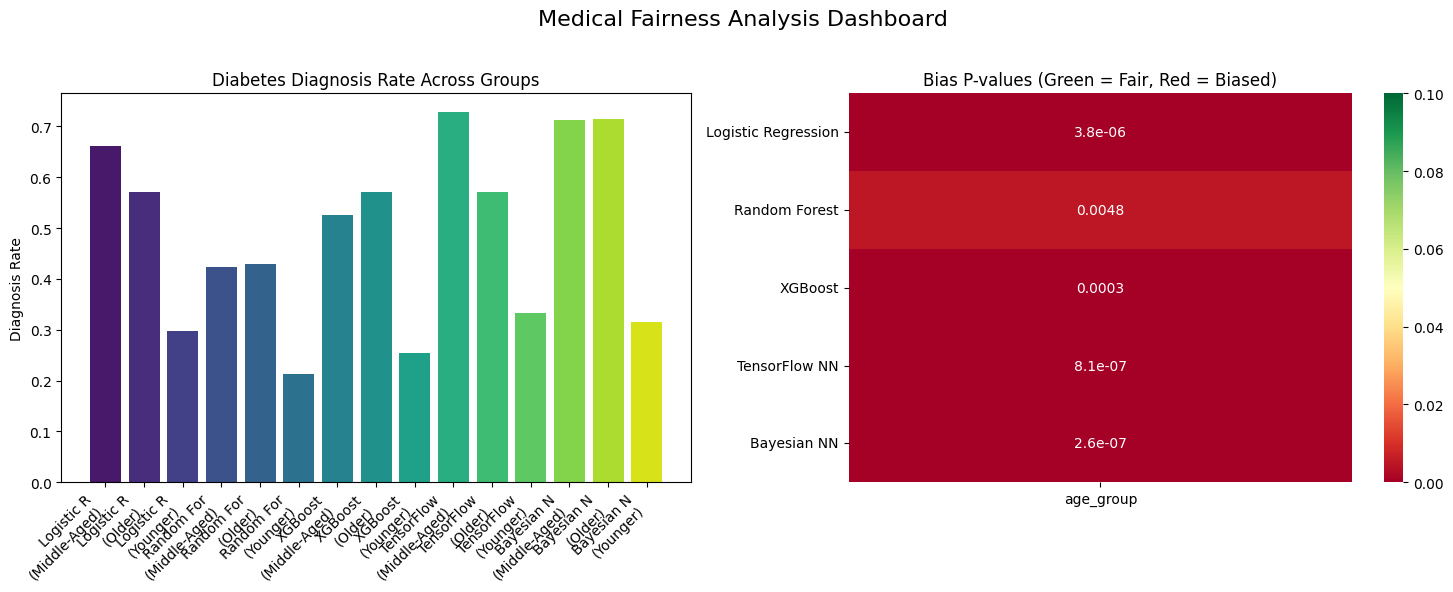

In [ ]:
fairness_results = fairness_analysis(models, X_test, y_test, df)

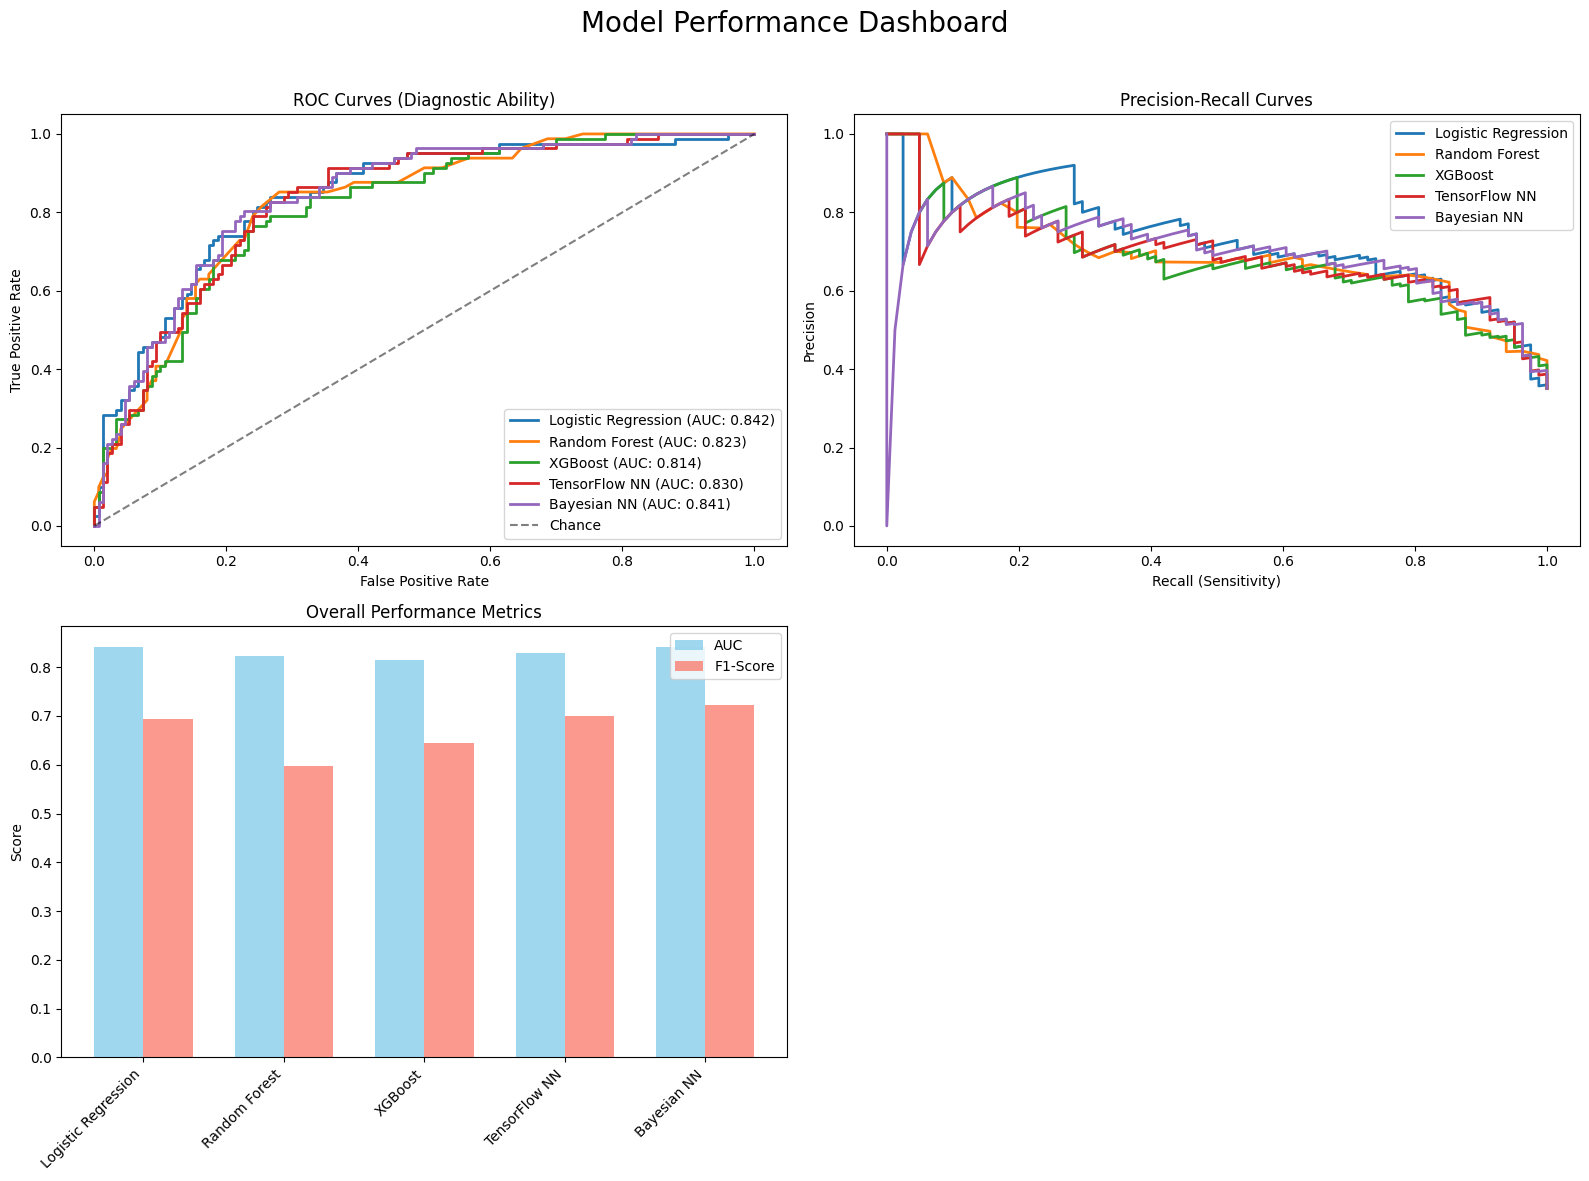

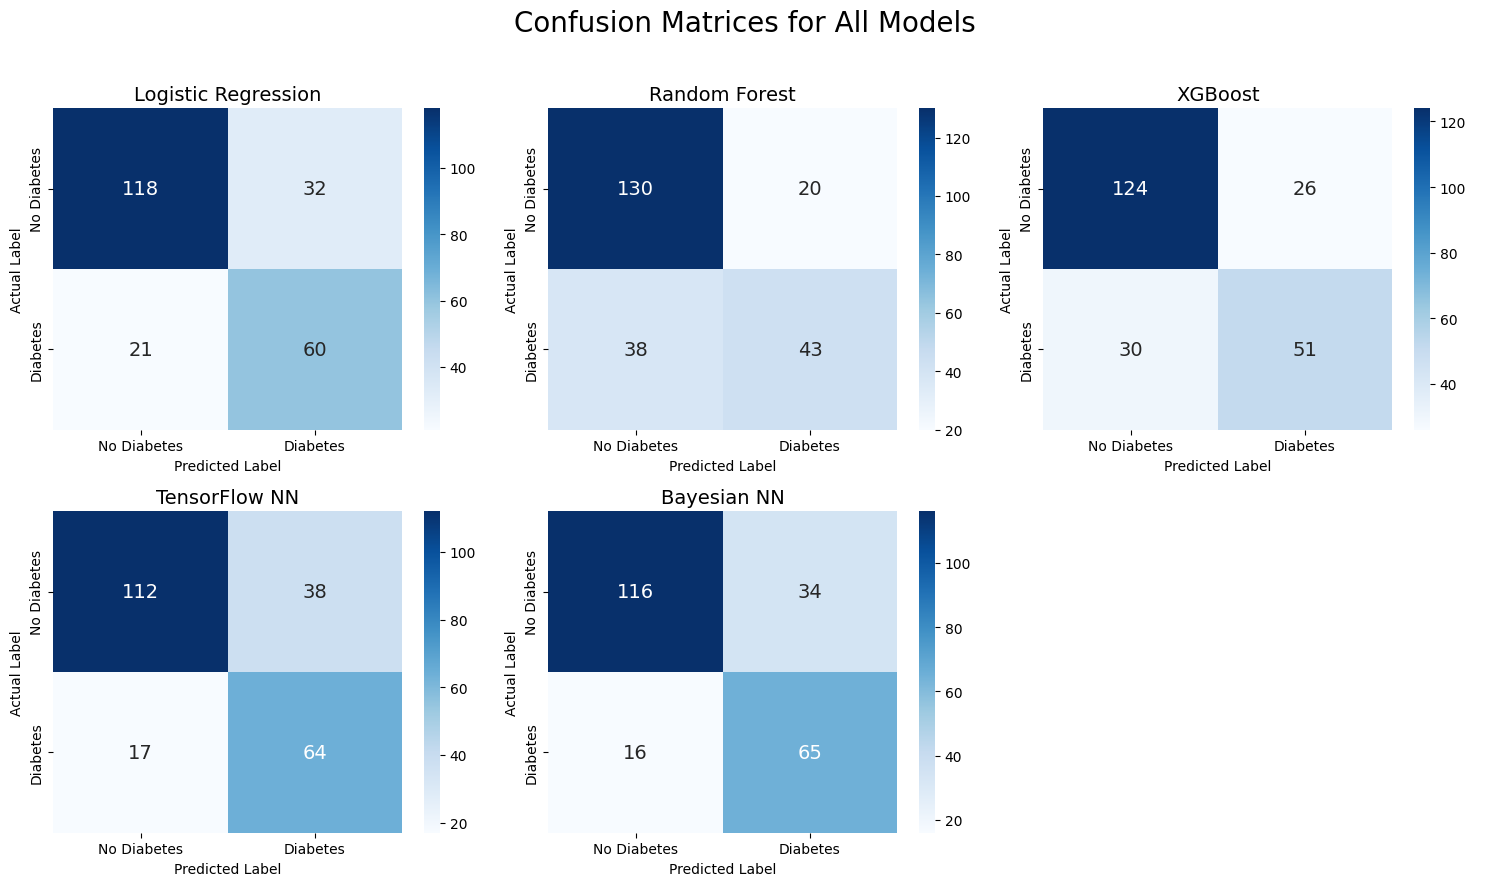

Model                | AUC      | F1-Score   | Accuracy   | Precision  | Recall    
--------------------------------------------------------------------------------
Logistic Regression  | 0.8421   | 0.6936     | 0.7706   | 0.6522    | 0.7407
Bayesian NN          | 0.8407   | 0.7222     | 0.7835   | 0.6566    | 0.8025
TensorFlow NN        | 0.8300   | 0.6995     | 0.7619   | 0.6275    | 0.7901
Random Forest        | 0.8233   | 0.5972     | 0.7489   | 0.6825    | 0.5309
XGBoost              | 0.8142   | 0.6456     | 0.7576   | 0.6623    | 0.6296


In [ ]:
model_evaluation(models, y_test)

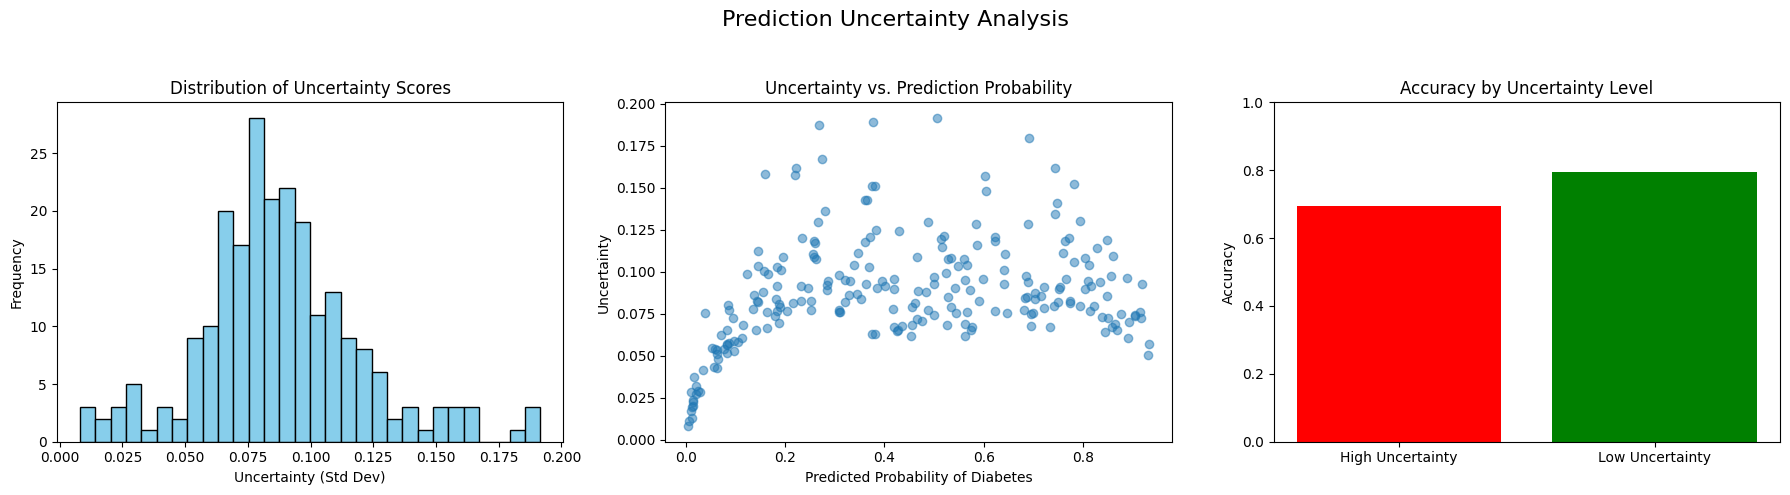

The model is much less accurate on its most uncertain predictions (69.57%)
Compared to its accuracy on more confident predictions (79.33%)
This is useful! We can flag highly uncertain cases for a human expert to review.


In [ ]:
uncertainty_analysis(models, X_test, y_test)

In [ ]:
comprehensive_report(models, fairness_results)

Best Overall Performer (AUC): Logistic Regression (AUC: 0.8421)
Best for Balanced Precision/Recall: Bayesian NN (F1-Score: 0.7222)

Fairness Assessment:
  - The 'Random Forest' model showed the least evidence of bias (p-value: 0.005).
